In [20]:
# Cell 1：掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# Cell 2：安裝 Tesseract 與 Python 套件
!apt-get update -qq
!apt-get install -y tesseract-ocr
!pip install -q pytesseract

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 9 not upgraded.


In [22]:
# Cell 3：匯入套件

import os
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pytesseract

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
# =========================
# Cell 4：路徑設定
# =========================
NPZ_PATH = "/content/drive/MyDrive/Colab Notebooks/data/printed_chars_dataset.npz"

RESULT_DIR = "/content/drive/MyDrive/Colab Notebooks/results"
os.makedirs(RESULT_DIR, exist_ok=True)

RESULT_TXT = os.path.join(RESULT_DIR, "result_ocr.txt")
RESULT_CSV = os.path.join(RESULT_DIR, "result_ocr.csv")

# =========================
# 若 npz 不存在，自動下載
# =========================
if not os.path.exists(NPZ_PATH):
    print("找不到 npz，開始下載...")

    os.makedirs(os.path.dirname(NPZ_PATH), exist_ok=True)

    !pip install -q gdown
    import gdown

    file_id = "1OuK9eYrdlXuYl_kbjMy27dW7dgzEnL3_"
    url = f"https://drive.google.com/uc?id={file_id}"

    gdown.download(url, NPZ_PATH, quiet=False)
    print("下載完成！")
else:
    print("已找到 npz，直接使用。")

print("NPZ_PATH =", NPZ_PATH)
print("RESULT_DIR =", RESULT_DIR)

已找到 npz，直接使用。
NPZ_PATH = /content/drive/MyDrive/Colab Notebooks/data/printed_chars_dataset.npz
RESULT_DIR = /content/drive/MyDrive/Colab Notebooks/results


In [24]:
# Cell 5：讀取 npz
data = np.load(NPZ_PATH, allow_pickle=True)

images = data["images"]         # shape: (N, 28, 28)
labels = data["labels"]         # shape: (N,)
label_names = data["label_names"]
filenames = data["filenames"]

print("images.shape =", images.shape)
print("labels.shape =", labels.shape)
print("label_names =", label_names)
print("前5個檔名 =", filenames[:5])

images.shape = (1800, 28, 28)
labels.shape = (1800,)
label_names = ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
前5個檔名 = ['0_AGENCYB.png' '0_AGENCYR.png' '0_ALGER.png' '0_ANTQUAB.png'
 '0_ANTQUABI.png']


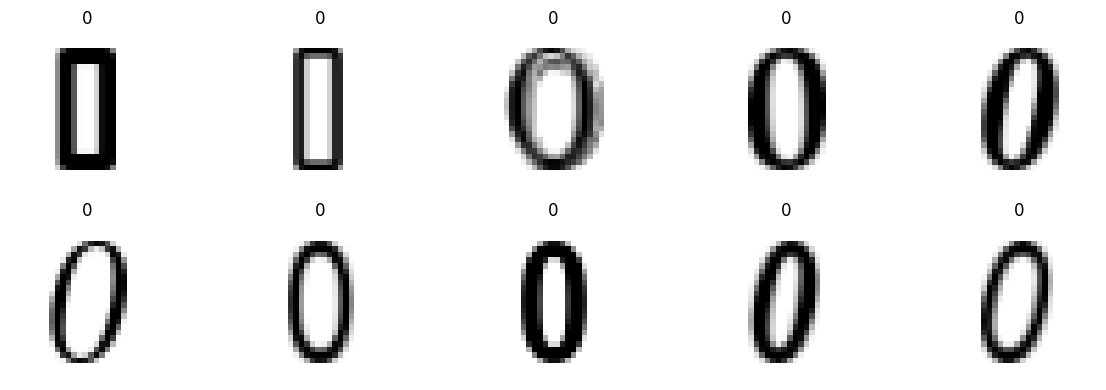

In [25]:
# Cell 6：顯示幾張範例圖
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(f"{label_names[labels[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# Cell 7：切分 train / test
indices = np.arange(len(images))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

X_test = images[test_idx]
y_test = labels[test_idx]

print("test size =", len(X_test))

test size = 360


In [27]:
# Cell 8：影像前處理函式
# Tesseract 對單字元小圖通常不太穩定，所以我們先做一些簡單前處理：放大、二值化
def preprocess_for_tesseract(img_28x28):
    """
    輸入:
        img_28x28: shape = (28, 28), uint8
    輸出:
        preprocessed image for tesseract
    """
    img = img_28x28.copy()

    # 放大，讓 OCR 比較容易辨識
    img = cv2.resize(img, (112, 112), interpolation=cv2.INTER_CUBIC)

    # 二值化
    _, img_bin = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)

    return img_bin

In [28]:
# Cell 9：OCR 單字元辨識函式
WHITELIST = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def ocr_single_char(img):
    """
    用 Tesseract 辨識單一字元
    回傳辨識結果字串
    """
    config = f'--psm 10 -c tessedit_char_whitelist={WHITELIST}'
    text = pytesseract.image_to_string(img, config=config)

    # 清理結果
    text = text.strip()

    # 若 OCR 回傳多個字，只取第一個
    if len(text) > 1:
        text = text[0]

    return text

In [29]:
# Cell 10：建立 label 對照
char_to_label = {ch: idx for idx, ch in enumerate(label_names)}
label_to_char = {idx: ch for idx, ch in enumerate(label_names)}

print(char_to_label)

{np.str_('0'): 0, np.str_('1'): 1, np.str_('2'): 2, np.str_('3'): 3, np.str_('4'): 4, np.str_('5'): 5, np.str_('6'): 6, np.str_('7'): 7, np.str_('8'): 8, np.str_('9'): 9, np.str_('A'): 10, np.str_('B'): 11, np.str_('C'): 12, np.str_('D'): 13, np.str_('E'): 14, np.str_('F'): 15, np.str_('G'): 16, np.str_('H'): 17, np.str_('I'): 18, np.str_('J'): 19, np.str_('K'): 20, np.str_('L'): 21, np.str_('M'): 22, np.str_('N'): 23, np.str_('O'): 24, np.str_('P'): 25, np.str_('Q'): 26, np.str_('R'): 27, np.str_('S'): 28, np.str_('T'): 29, np.str_('U'): 30, np.str_('V'): 31, np.str_('W'): 32, np.str_('X'): 33, np.str_('Y'): 34, np.str_('Z'): 35}


In [30]:
# Cell 11：逐張 OCR 辨識並計時
y_pred = []
raw_texts = []

infer_start = time.perf_counter()

for img in X_test:
    img_pre = preprocess_for_tesseract(img)
    pred_char = ocr_single_char(img_pre)
    raw_texts.append(pred_char)

    if pred_char in char_to_label:
        y_pred.append(char_to_label[pred_char])
    else:
        # 若辨識失敗，給 -1
        y_pred.append(-1)

infer_end = time.perf_counter()

total_infer_time_sec = infer_end - infer_start
avg_infer_time_ms = (total_infer_time_sec / len(X_test)) * 1000

y_pred = np.array(y_pred)

print(f"OCR 整批推論時間: {total_infer_time_sec:.6f} 秒")
print(f"OCR 平均每張推論時間: {avg_infer_time_ms:.6f} ms")

OCR 整批推論時間: 74.000315 秒
OCR 平均每張推論時間: 205.556431 ms


In [31]:
# Cell 12：計算準確率
acc = accuracy_score(y_test, y_pred)
print(f"OCR Accuracy = {acc:.4f}")

OCR Accuracy = 0.8611


In [32]:
# Cell 13：統計辨識失敗數量
fail_count = np.sum(y_pred == -1)
print(f"辨識失敗數量: {fail_count}")
print(f"辨識失敗比例: {fail_count / len(y_pred):.4f}")

辨識失敗數量: 40
辨識失敗比例: 0.1111


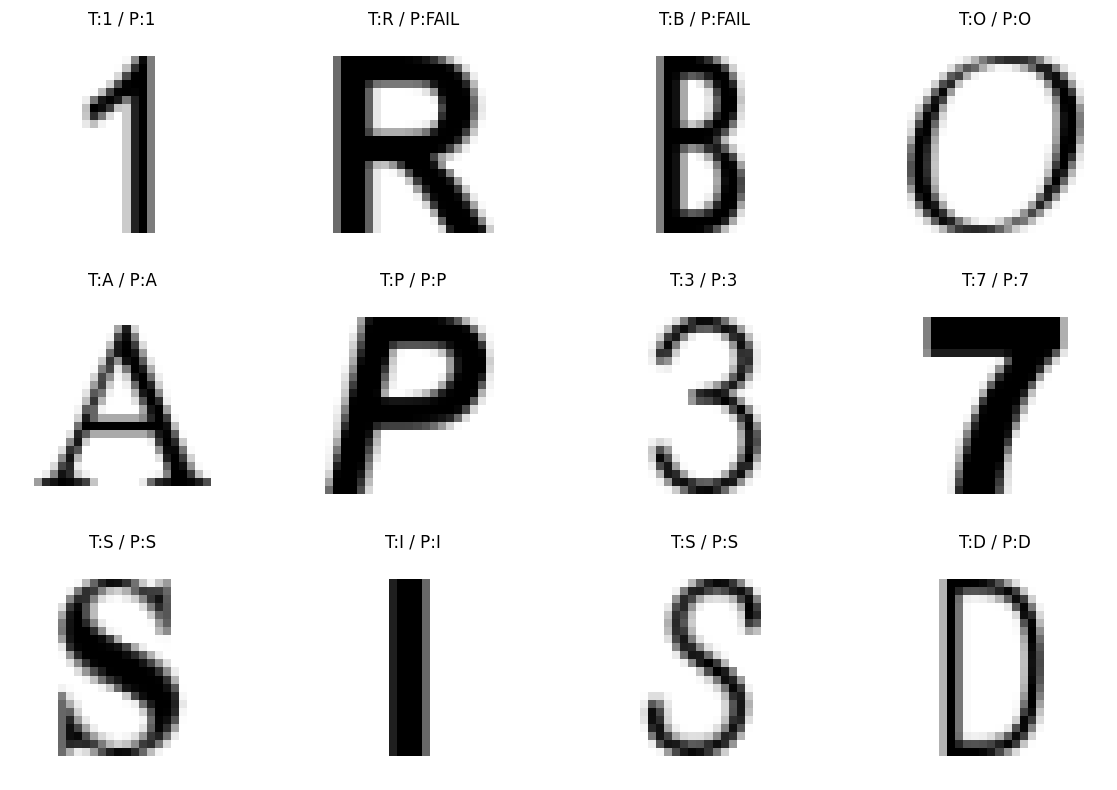

In [33]:
# Cell 14：顯示部分預測結果
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")

    true_char = label_to_char[y_test[i]]
    pred_char = "FAIL" if y_pred[i] == -1 else label_to_char[y_pred[i]]

    plt.title(f"T:{true_char} / P:{pred_char}")
    plt.axis("off")

plt.tight_layout()
plt.show()

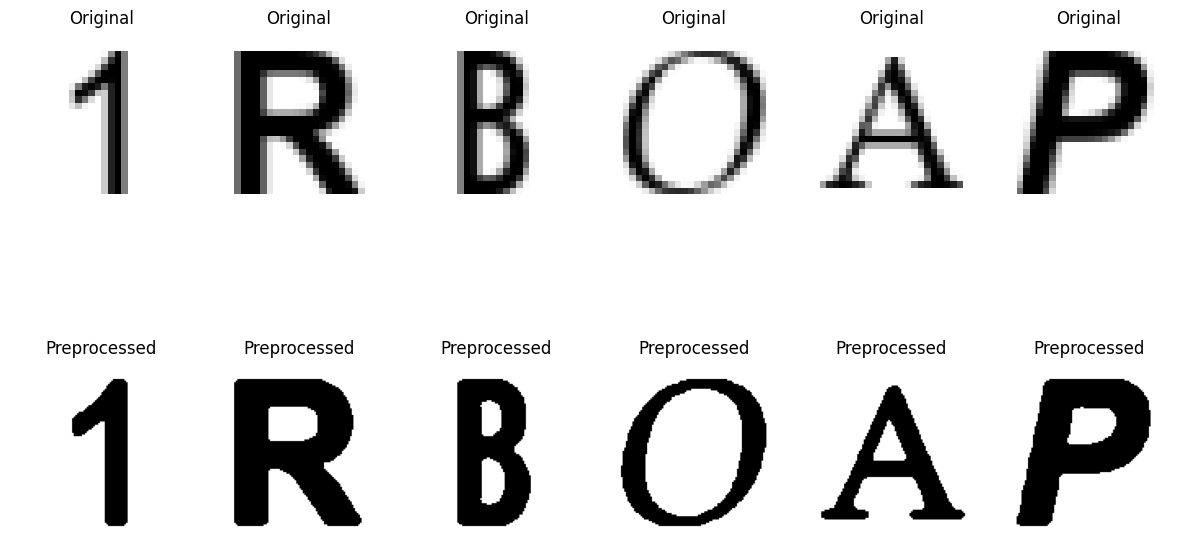

In [34]:
# Cell 15：顯示前處理後的影像
plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 6, i + 7)
    plt.imshow(preprocess_for_tesseract(X_test[i]), cmap="gray")
    plt.title("Preprocessed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# Cell 16：分類報告
valid_mask = (y_pred != -1)

if np.sum(valid_mask) > 0:
    report = classification_report(
        y_test[valid_mask],
        y_pred[valid_mask],
        target_names=label_names,
        digits=4,
        zero_division=0
    )
    print(report)
else:
    print("沒有有效辨識結果，無法產生 classification report。")

              precision    recall  f1-score   support

           0     1.0000    0.8889    0.9412         9
           1     0.7778    0.8750    0.8235         8
           2     0.9000    1.0000    0.9474         9
           3     1.0000    1.0000    1.0000        10
           4     1.0000    1.0000    1.0000         6
           5     1.0000    1.0000    1.0000         8
           6     1.0000    0.8889    0.9412         9
           7     1.0000    0.7778    0.8750         9
           8     1.0000    1.0000    1.0000         9
           9     1.0000    1.0000    1.0000         8
           A     0.9091    1.0000    0.9524        10
           B     1.0000    1.0000    1.0000         6
           C     1.0000    1.0000    1.0000        10
           D     0.9000    1.0000    0.9474         9
           E     1.0000    1.0000    1.0000        10
           F     1.0000    1.0000    1.0000        10
           G     1.0000    1.0000    1.0000        10
           H     1.0000    

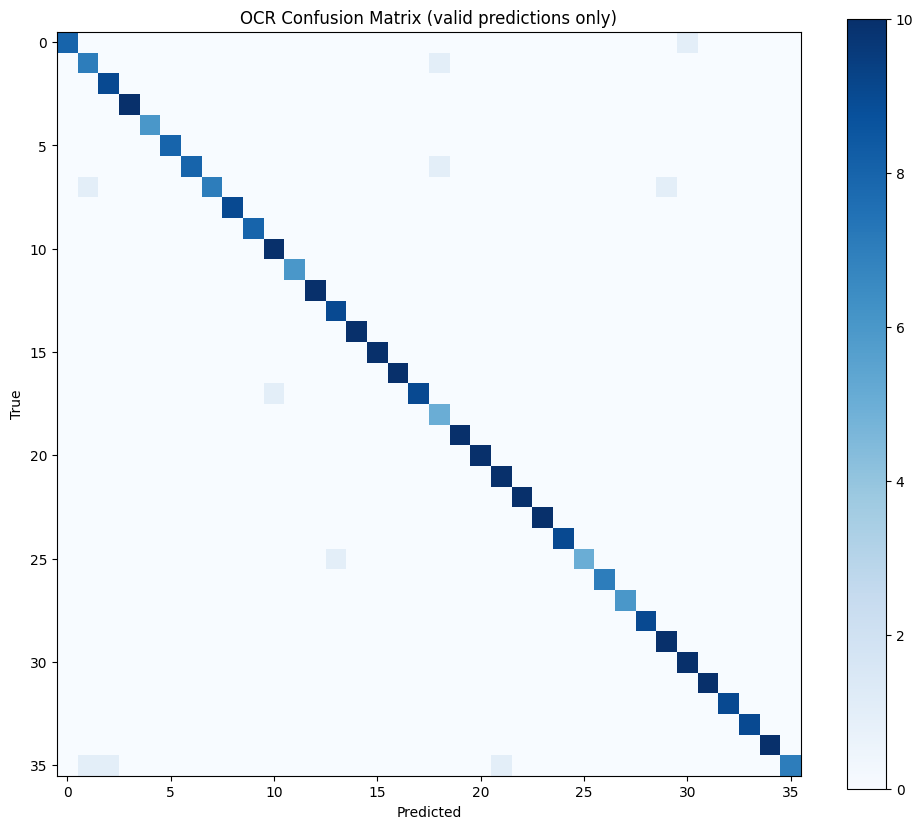

In [36]:
# Cell 17：混淆矩陣
if np.sum(valid_mask) > 0:
    cm = confusion_matrix(y_test[valid_mask], y_pred[valid_mask])

    plt.figure(figsize=(12, 10))
    plt.imshow(cm, cmap="Blues")
    plt.title("OCR Confusion Matrix (valid predictions only)")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
else:
    print("沒有有效辨識結果，無法繪製混淆矩陣。")

In [37]:
# Cell 18：將結果寫入 TXT
with open(RESULT_TXT, "w", encoding="utf-8") as f:
    f.write("method=OCR\n")
    f.write("device=CPU\n")
    f.write("train_samples=0\n")
    f.write(f"test_samples={len(X_test)}\n")
    f.write(f"accuracy={acc:.6f}\n")
    f.write("train_time_sec=0.000000\n")
    f.write(f"total_infer_time_sec={total_infer_time_sec:.6f}\n")
    f.write(f"avg_infer_time_ms={avg_infer_time_ms:.6f}\n")
    f.write(f"failed_count={fail_count}\n")
    f.write("extra_note=Tesseract OCR, psm=10, whitelist=0-9A-Z\n")

print(f"TXT 已儲存到：{RESULT_TXT}")

# Cell 19：將摘要結果寫入 CSV
file_exists = os.path.exists(RESULT_CSV)

with open(RESULT_CSV, "a", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)

    if not file_exists:
        writer.writerow([
            "method",
            "device",
            "train_samples",
            "test_samples",
            "accuracy",
            "train_time_sec",
            "total_infer_time_sec",
            "avg_infer_time_ms",
            "extra_note"
        ])

    writer.writerow([
        "OCR",
        "CPU",
        0,
        len(X_test),
        f"{acc:.6f}",
        f"{0.0:.6f}",
        f"{total_infer_time_sec:.6f}",
        f"{avg_infer_time_ms:.6f}",
        f"failed={fail_count}; Tesseract psm10 whitelist"
    ])

print(f"CSV 已更新：{RESULT_CSV}")

TXT 已儲存到：/content/drive/MyDrive/Colab Notebooks/results/result_ocr.txt
CSV 已更新：/content/drive/MyDrive/Colab Notebooks/results/result_ocr.csv
